# A whole language model, in 70 000 parameters

Everything from the last hour, end to end and small enough to watch:

1. a **vocabulary** (the frozen index),
2. a **transformer** (~72k parameters, 2 layers, 4 heads),
3. **training** with warmup + cosine decay,
4. **generation**, sampled at several points during training so you can see it learn,
5. a **temperature sweep** that measures the creativity/correctness trade-off.

Trains in about **6 seconds on a CPU**. No downloads, no dataset files.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import math, random, time
import matplotlib.pyplot as plt
import tqdm

torch.manual_seed(0); random.seed(0)
print("torch", torch.__version__)

torch 2.10.0


---
## 1. A corpus with a hidden rule

Rather than download text, we generate it from a small grammar. Every sentence looks like

```
DET  PERSON  VERB  DET  EQUIPMENT  ADVERB  .
```

but there is a **rule the model is not told**: each verb only accepts certain objects.
You can *align* a beam or a magnet, but you cannot *align* a trigger. Learning that rule is the
thing we will test, because it cannot be guessed from word order alone.

We enumerate every legal sentence, train on 60% of them, and keep the rest hidden. Then we can
ask whether generated sentences are (a) grammatical and (b) ones the model **never saw**.

In [2]:
DET    = ["the", "a"]
PERSON = ["physicist", "student", "engineer", "technician"]
ADV    = ["carefully", "twice", "again", "yesterday"]
VERB_OBJ = {                                  # <- the hidden rule
    "calibrated": ["detector", "magnet", "calorimeter"],
    "aligned":    ["beam", "magnet"],
    "measured":   ["beam", "trigger", "calorimeter"],
    "rebuilt":    ["detector", "trigger"],
    "checked":    ["magnet", "trigger", "calorimeter"],
}
VALID_PAIRS = {(v, o) for v, objs in VERB_OBJ.items() for o in objs}

SENTS = [f"{d1} {p} {v} {d2} {o} {a} ."
         for d1 in DET for p in PERSON
         for v, objs in VERB_OBJ.items() for o in objs
         for d2 in DET for a in ADV]
random.shuffle(SENTS)
cut = int(0.6 * len(SENTS))
TRAIN, HELD = SENTS[:cut], set(SENTS[cut:])

print(f"{len(SENTS)} legal sentences | training on {len(TRAIN)} | {len(HELD)} held out")
for s in TRAIN[:4]: print("   ", s)

832 legal sentences | training on 499 | 333 held out
    a engineer checked a trigger twice .
    a engineer checked the trigger twice .
    the engineer checked a trigger yesterday .
    the physicist measured the trigger twice .


---
## 2. The vocabulary: a frozen index

`stoi` maps text to integers and never changes.
`nn.Embedding` will map those integers to vectors, and *that* part is learned.

In [3]:
BOS = "<bos>" #beginning of sequence - something to condition on
itos = [BOS] + sorted({w for s in SENTS for w in s.split()})
stoi = {w: i for i, w in enumerate(itos)}
V = len(itos)

def encode(s): return [stoi[BOS]] + [stoi[w] for w in s.split()]
def decode(ids): return " ".join(itos[i] for i in ids if itos[i] != BOS)

print("vocab size:", V)
print(itos)
print()
print(TRAIN[0])
print(encode(TRAIN[0]))

L = len(encode(TRAIN[0]))
data = torch.tensor([encode(s) for s in TRAIN])
print("\nsequence length:", L, " data tensor:", tuple(data.shape))

vocab size: 22
['<bos>', '.', 'a', 'again', 'aligned', 'beam', 'calibrated', 'calorimeter', 'carefully', 'checked', 'detector', 'engineer', 'magnet', 'measured', 'physicist', 'rebuilt', 'student', 'technician', 'the', 'trigger', 'twice', 'yesterday']

a engineer checked a trigger twice .
[0, 2, 11, 9, 2, 19, 20, 1]

sequence length: 8  data tensor: (499, 8)


---
## 3. The model

Two blocks, four heads, $d = 64$. Pre-LN, causal mask, learned positional embeddings — the
architecture at 1/1700th the size of GPT-2 small.

In [4]:
class Block(nn.Module):
    def __init__(self, d, nh, ff):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, nh, batch_first=True)
        self.ff   = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d))
    def forward(self, x, mask):
        h = self.n1(x)
        a, _ = self.attn(h, h, h, attn_mask=mask, need_weights=False)
        x = x + a                                  # residual
        return x + self.ff(self.n2(x))             # residual

class MiniLM(nn.Module):
    def __init__(self, V, d=64, nh=4, nl=2, ff=128, maxlen=32):
        super().__init__()
        self.emb, self.pos = nn.Embedding(V, d), nn.Embedding(maxlen, d)
        self.blocks = nn.ModuleList([Block(d, nh, ff) for _ in range(nl)])
        self.nf, self.head = nn.LayerNorm(d), nn.Linear(d, V)   # ln_f, then the LM head
    def forward(self, x):
        n = x.shape[1]
        mask = torch.triu(torch.ones(n, n, dtype=torch.bool), 1)   # causal
        h = self.emb(x) + self.pos(torch.arange(n))[None]
        for b in self.blocks: h = b(h, mask)
        return self.head(self.nf(h))

model = MiniLM(V)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

71,958 parameters


---
## 4. Sampling

Standard autoregressive decoding: start from `<bos>`, take the logits at the last position,
divide by the temperature, sample, append, repeat.

In [5]:
@torch.no_grad()
def generate(m, n=5, temp=1.0, top_k=None):
    m.eval()
    x = torch.full((n, 1), stoi[BOS])
    for _ in range(L - 1):
        logits = m(x)[:, -1] / temp
        if top_k:
            kth = logits.topk(top_k, dim=-1).values[:, -1:]
            logits = logits.masked_fill(logits < kth, float("-inf"))
        x = torch.cat([x, torch.multinomial(logits.softmax(-1), 1)], dim=1)
    m.train()
    return [decode(r.tolist()) for r in x]

def score(sents):
    "fraction grammatical (obeys the hidden rule), and fraction that were held out"
    ok = novel = 0
    for s in sents:
        w = s.split()
        if (len(w) == 7 and w[0] in DET and w[1] in PERSON and w[3] in DET
                and w[5] in ADV and w[6] == "." and (w[2], w[4]) in VALID_PAIRS):
            ok += 1
            if s in HELD: novel += 1
    return ok / len(sents), novel / len(sents)

print("before any training:")
for s in generate(model, 3): print("   ", s)

before any training:
    aligned aligned beam aligned . carefully physicist
    aligned magnet calibrated calibrated physicist trigger
    engineer rebuilt magnet calorimeter aligned magnet engineer


---
## 5. Training

AdamW, $\beta_1{=}0.9$, $\beta_2{=}0.95$, gradient clipping at 1.0, and the
**linear warmup + cosine decay** schedule from the optimisation slide. We log both the loss and
the learning rate, and sample a few sentences at fixed checkpoints.

100%|██████████| 1500/1500 [34:25<00:00,  1.38s/it]


trained in 2066s, final loss 0.924


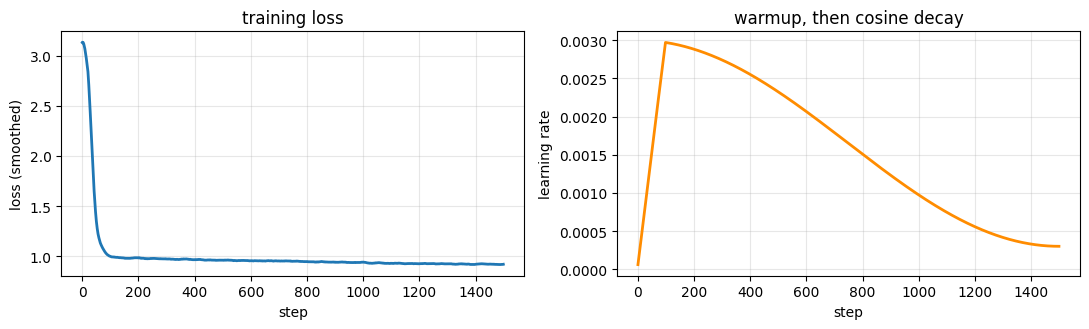

In [6]:
STEPS, WARMUP = 1500, 100
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, betas=(0.9, 0.95), weight_decay=0.1)
sched = torch.optim.lr_scheduler.LambdaLR(
    opt, lambda s: min((s + 1) / WARMUP, 1.0) *
                   (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * min(s / STEPS, 1)))))

CHECKPOINTS = [0, 50, 200, 600, STEPS - 1]
losses, lrs, snapshots = [], [], {}
t0 = time.time()
for s in tqdm.tqdm(range(STEPS)):
    if s in CHECKPOINTS: snapshots[s] = generate(model, 3)
    b = data[torch.randint(0, len(data), (64,))]
    loss = F.cross_entropy(model(b[:, :-1]).reshape(-1, V), b[:, 1:].reshape(-1))
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); sched.step()
    losses.append(loss.item()); lrs.append(sched.get_last_lr()[0])
print(f"trained in {time.time() - t0:.0f}s, final loss {losses[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
k = 20
sm = [sum(losses[max(0, i-k):i+1]) / len(losses[max(0, i-k):i+1]) for i in range(len(losses))]
ax[0].plot(sm, lw=2); ax[0].set_xlabel("step"); ax[0].set_ylabel("loss (smoothed)")
ax[0].set_title("training loss"); ax[0].grid(alpha=.3)
ax[1].plot(lrs, lw=2, color="darkorange"); ax[1].set_xlabel("step")
ax[1].set_ylabel("learning rate"); ax[1].set_title("warmup, then cosine decay"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 6. Watch it learn

This is the part to run live.

In [7]:
for s in CHECKPOINTS:
    print(f"--- step {s} " + "-" * 40)
    for x in snapshots[s]: print("   ", x)
    print()

--- step 0 ----------------------------------------
    the trigger trigger aligned calorimeter technician carefully
    engineer magnet magnet yesterday calorimeter measured measured
    rebuilt . student the again physicist engineer

--- step 50 ----------------------------------------
    a calorimeter magnet physicist engineer rebuilt .
    a physicist measured a beam again .
    the engineer measured the detector yesterday .

--- step 200 ----------------------------------------
    the physicist calibrated the calorimeter again .
    the technician measured the trigger carefully .
    the technician checked a trigger again .

--- step 600 ----------------------------------------
    the student aligned technician magnet twice .
    the physicist checked a calorimeter twice .
    the student calibrated a calorimeter carefully .

--- step 1499 ----------------------------------------
    the engineer calibrated a calorimeter twice .
    a technician measured a trigger again .
    t

Word salad, then the *shape* of a sentence, then correct sentences. Nothing about this staging
was designed, but it falls out of minimising next-token loss.

Watch the **order in which things are learned**. Sentence length and the closing full stop come
first, then determiner-before-noun, then which nouns can be subjects, and only last the
verb-object rule. Frequent, local structure is cheap to learn; rarer, longer-range constraints
come later. Real LLM training shows the same ordering, but are trained over months instead of minutes.

---
## 7. Temperature: correctness against novelty

Now sample 200 sentences at each temperature and measure two things: what fraction obey the
hidden verb--object rule, and what fraction are sentences the model was **never trained on**.

In [8]:
print(f"{'temp':>6} {'grammatical':>13} {'held-out (novel)':>18}")
for T in [0.3, 0.5, 1.0, 1.5, 2.0]:
    g = generate(model, 300, temp=T)
    ok, novel = score(g)
    print(f"{T:6.1f} {ok*100:12.1f}% {novel*100:17.1f}%")

print("\nsamples at temperature 1.0:")
for s in generate(model, 6): print("   ", s)

  temp   grammatical   held-out (novel)
   0.3        100.0%               2.3%
   0.5        100.0%               2.0%
   1.0         99.0%               8.7%
   1.5         84.0%              15.0%
   2.0         53.7%               7.3%

samples at temperature 1.0:
    the engineer measured a beam again .
    a student checked a trigger again .
    the physicist rebuilt a trigger again .
    a engineer rebuilt a detector twice .
    a physicist aligned the beam carefully .
    a student calibrated a detector yesterday .
